**Step 1: Environment Initialization & Code Extraction**


In [1]:
# 1. Reset the workspace environment completely
!rm -rf TrackNet-master TrackNet

# 2. Clone the authentic weekenddeeplearning repository structure
!git clone https://github.com/weekenddeeplearning/TrackNet.git
!mv TrackNet TrackNet-master

# 3. Force installation of compatible deep learning libraries
!pip install opencv-python pandas filterpy matplotlib tqdm

Cloning into 'TrackNet'...
remote: Enumerating objects: 70, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 70 (delta 2), reused 1 (delta 0), pack-reused 64 (from 1)
Receiving objects: 100% (70/70), 104.27 MiB | 24.36 MiB/s, done.
Resolving deltas: 100% (12/12), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 10.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110460 sha256=b3427cfbbcce6fb6854f4120df810df6f08fb7727f41ba3b72d63bf94b35d10a
  Stored in directory: /root/.cache/pip/wheels/77/bf/4c/b0c3f4798a0166668752312a67118b27a3cd341e13ac0ae6ee
Successfully built filterpy


**Step 2: Mount Drive & High-Speed Dataset Extraction & Adaptation (Raw .mp4 -> Frames)**


In [2]:
import cv2
import glob
import os
import shutil
import zipfile
import numpy as np
import pandas as pd
from google.colab import drive

# --- SUBSET CONFIGURATION PARAMETERS ---
MAX_CLIPS_TO_PROCESS = 2  # Limits the number of video files processed
MAX_FRAMES_PER_CLIP = 450  # Caps the frame depth per video to keep execution rapid
# ---------------------------------------

# 1. Mount Google Drive
drive.mount("/content/drive")

# 2. Define path configurations
drive_zip_path = "/content/drive/MyDrive/EE584_Project/back_view.zip"
local_raw_tmp = "/content/local_back_view_raw"
local_extract_base = "/content/TrackNet-master/Dataset_Images"

# Clear workspace directories to guarantee a clean run
for folder in [local_raw_tmp, local_extract_base]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder, exist_ok=True)

# 3. Extract Zip Archive Locally
if os.path.exists(drive_zip_path):
    print(f"Unpacking {drive_zip_path} to local scratch memory...")
    with zipfile.ZipFile(drive_zip_path, "r") as zip_ref:
        zip_ref.extractall(local_raw_tmp)
    print("Archive unpacked successfully!")
else:
    print(
        f"ERROR: Zipped data archive not found at target path: {drive_zip_path}"
    )


# 4. Preprocessing Adapter Script with explicit Sub-Sampling caps
def build_tracknet_subset_from_pairs(raw_dir, output_dir):
    video_files = []
    for root, _, files in os.walk(raw_dir):
        for file in files:
            # FIX: Explicitly ignore hidden macOS metadata files starting with '.'
            if file.endswith(".mp4") and not file.startswith("."):
                video_files.append((root, file))

    if not video_files:
        print("ERROR: No valid .mp4 files discovered inside the extracted zip!")
        return

    # Sort and slice the valid video list to enforce the clip limit cap
    video_files = sorted(video_files)[:MAX_CLIPS_TO_PROCESS]
    print(
        f"Sub-sampling active: Only the first {len(video_files)} valid clips will be parsed."
    )

    for root_dir, video_name in video_files:
        video_id = video_name.split(".")[0]
        video_path = os.path.join(root_dir, video_name)
        ball_csv_path = os.path.join(root_dir, f"{video_id}_ball.csv")

        if not os.path.exists(ball_csv_path):
            print(
                f"Skipping sequence {video_name}: Corresponding ball tracking CSV not found."
            )
            continue

        print(f"Processing sequence pair: {video_id}...")

        # Read the unique format ball coordinates
        df_ball = pd.read_csv(ball_csv_path)
        df_ball.columns = [str(c).strip().lower() for c in df_ball.columns]

        # Read keys into lookup dictionary
        annotation_dict = {}
        for _, row in df_ball.iterrows():
            f_str = str(row["frame"]).strip()
            annotation_dict[f_str] = (
                float(row["ball_x"]),
                float(row["ball_y"]),
            )

        # Build output directory path matching standard structure loops
        sequence_folder = os.path.join(
            output_dir, "Dataset", "game_adversarial", f"clip_{video_id}"
        )
        os.makedirs(sequence_folder, exist_ok=True)

        cap = cv2.VideoCapture(video_path)
        frame_idx = 0
        tracknet_labels = []
        target_w, target_h = 640, 360

        while cap.isOpened():
            # Break out early if the current clip hits our frame depth limit
            if frame_idx >= MAX_FRAMES_PER_CLIP:
                print(f" -> Reached subset ceiling of {MAX_FRAMES_PER_CLIP} frames.")
                break

            ret, frame = cap.read()
            if not ret:
                break

            orig_h, orig_w = frame.shape[:2]
            resized_frame = cv2.resize(frame, (target_w, target_h))

            csv_frame_key = f"frame_{frame_idx:03d}"
            frame_name = f"{frame_idx:04d}.jpg"

            # Write individual target frame slice
            cv2.imwrite(
                os.path.join(sequence_folder, frame_name), resized_frame
            )

            if csv_frame_key in annotation_dict:
                raw_x, raw_y = annotation_dict[csv_frame_key]

                # Clean up outer out-of-frame indicator values
                if np.isnan(raw_x) or raw_x >= (orig_w - 20) or raw_x < 0:
                    scale_x, scale_y = 0, 0
                    visibility = 0
                else:
                    # Linearly rescale ground truth labels to match the 640x360 window
                    scale_x = int(raw_x * (target_w / orig_w))
                    scale_y = int(raw_y * (target_h / orig_h))
                    visibility = 1
            else:
                scale_x, scale_y = 0, 0
                visibility = 0

            tracknet_labels.append([frame_name, visibility, scale_x, scale_y])
            frame_idx += 1

        cap.release()

        # Save standardized Label file
        label_df = pd.DataFrame(
            tracknet_labels, columns=["frame", "visibility", "x", "y"]
        )
        label_df.to_csv(
            os.path.join(sequence_folder, "Label.csv"), index=False
        )
        print(
            f"Successfully saved clean subset slice for clip_{video_id} ({frame_idx} frames)."
        )


# Run subset generation
build_tracknet_subset_from_pairs(local_raw_tmp, local_extract_base)

Mounted at /content/drive
Unpacking /content/drive/MyDrive/EE584_Project/back_view.zip to local scratch memory...
Archive unpacked successfully!
Sub-sampling active: Only the first 2 valid clips will be parsed.
Processing sequence pair: video1...
 -> Reached subset ceiling of 450 frames.
Successfully saved clean subset slice for clip_video1 (450 frames).
Processing sequence pair: video10...
Successfully saved clean subset slice for clip_video10 (226 frames).


**Step 3: Shared Core Configurations & Dataset Freezing**


In [3]:
import glob
import os
import pandas as pd

local_extract_base = "/content/TrackNet-master/Dataset_Images"


def parse_flexible_csv(csv_path):
    try:
        df = pd.read_csv(csv_path)
        df.columns = [str(c).strip().lower() for c in df.columns]
        if str(df.columns[0]).endswith(".jpg") or str(df.columns[0]).isdigit():
            df = pd.read_csv(csv_path, header=None)
            df.columns = ["frame", "visibility", "x", "y"]
        rename_map = {}
        for col in df.columns:
            if any(
                k in col for k in ["frame", "file", "img", "image", "name"]
            ):
                rename_map[col] = "frame"
            elif any(k in col for k in ["vis", "visibility"]):
                rename_map[col] = "visibility"
            elif "x" in col:
                rename_map[col] = "x"
            elif "y" in col:
                rename_map[col] = "y"
        return df.rename(columns=rename_map)
    except Exception:
        return None


all_discovered_clips = sorted(
    glob.glob(os.path.join(local_extract_base, "**", "*.csv"), recursive=True)
)

valid_clips_data = []
total_frame_workload = 0

for csv_path in all_discovered_clips:
    df_clip = parse_flexible_csv(csv_path)
    if df_clip is not None and len(df_clip) >= 3:
        total_frame_workload += len(df_clip) - 2
        valid_clips_data.append((csv_path, df_clip))

print("=" * 60)
print(f"SUBSET DATASET LOCK COMPLETE")
print(
    f"Total Workload Restricted To: {total_frame_workload} frames across {len(valid_clips_data)} clips."
)
print("=" * 60)

SUBSET DATASET LOCK COMPLETE
Total Workload Restricted To: 672 frames across 2 clips.


**Step 4: TrackNet Model II Inference & Verification Execution**


In [4]:
import os
import cv2
import numpy as np
from tqdm import tqdm

%cd /content/TrackNet-master/Code_Tennis
from Models.TrackNet import TrackNet

weights_path = "/content/TrackNet-master/Code_Tennis/weights/model_tennis.h5"
width, height = 640, 360
n_classes = 256
pe_threshold = 5

m = TrackNet(n_classes, input_height=height, input_width=width)
m.compile(
    loss="categorical_crossentropy", optimizer="adadelta", metrics=["accuracy"]
)
m.load_weights(weights_path)
print(
    "\nTrackNet Spatio-Temporal Model II successfully loaded with frozen weights.\n"
)

tracknet_tp, tracknet_fp, tracknet_fn = 0, 0, 0
tracknet_pe_list = []
tracknet_predictions = {}   # {int_frame_idx -> (pred_x, pred_y)} for the on-the-fly video

with tqdm(
    total=total_frame_workload, desc="Evaluating TrackNet Model II", unit="frame"
) as pbar:
    for csv_path, df_clip in sorted(valid_clips_data, key=lambda x: x[0]):
        clip_dir = os.path.dirname(csv_path)

        for i in range(2, len(df_clip)):
            pbar.update(1)

            gt_row = df_clip.iloc[i]
            vc_gt = int(float(gt_row["visibility"]))
            gt_x, gt_y = float(gt_row["x"]), float(gt_row["y"])

            f_t = str(df_clip.iloc[i]["frame"])
            f_t1 = str(df_clip.iloc[i - 1]["frame"])
            f_t2 = str(df_clip.iloc[i - 2]["frame"])

            if not f_t.lower().endswith((".jpg", ".png", ".jpeg")):
                f_t, f_t1, f_t2 = f_t + ".jpg", f_t1 + ".jpg", f_t2 + ".jpg"

            path_t = os.path.join(clip_dir, f_t)
            path_t1 = os.path.join(clip_dir, f_t1)
            path_t2 = os.path.join(clip_dir, f_t2)

            if not (
                os.path.exists(path_t)
                and os.path.exists(path_t1)
                and os.path.exists(path_t2)
            ):
                continue

            raw_frame = cv2.imread(path_t)
            if raw_frame is None:
                continue
            orig_h, orig_w, _ = raw_frame.shape

            img = cv2.resize(raw_frame, (width, height)).astype(np.float32)
            img1 = cv2.resize(cv2.imread(path_t1), (width, height)).astype(
                np.float32
            )
            img2 = cv2.resize(cv2.imread(path_t2), (width, height)).astype(
                np.float32
            )

            X = np.concatenate((img, img1, img2), axis=2)
            X = np.rollaxis(X, 2, 0)

            pr = m.predict(np.array([X]), verbose=0)[0]
            pr = (
                pr.reshape((height, width, n_classes))
                .argmax(axis=2)
                .astype(np.uint8)
            )

            heatmap_resized = cv2.resize(pr, (orig_w, orig_h))
            _, heatmap = cv2.threshold(
                heatmap_resized, 127, 255, cv2.THRESH_BINARY
            )

            circles = cv2.HoughCircles(
                heatmap,
                cv2.HOUGH_GRADIENT,
                dp=1,
                minDist=1,
                param1=50,
                param2=2,
                minRadius=2,
                maxRadius=7,
            )

            vc_pred = 1 if circles is not None else 0
            pred_x = int(circles[0][0][0]) if vc_pred == 1 else 0
            pred_y = int(circles[0][0][1]) if vc_pred == 1 else 0

            # Capture SoTA centroid for the on-the-fly verification video (Step 9).
            # Key by INTEGER frame index ('0007.jpg' -> 7) to map against VideoCapture.
            if vc_pred == 1:
                tracknet_predictions[int(f_t.split('.')[0])] = (pred_x, pred_y)

            if vc_gt == 0:
                if vc_pred == 1:
                    tracknet_fp += 1
            else:
                if vc_pred == 0:
                    tracknet_fn += 1
                else:
                    pe = np.sqrt((gt_x - pred_x) ** 2 + (gt_y - pred_y) ** 2)
                    tracknet_pe_list.append(pe)
                    if pe <= pe_threshold:
                        tracknet_tp += 1
                    else:
                        tracknet_fp += 1

tn_precision = (
    tracknet_tp / (tracknet_tp + tracknet_fp)
    if (tracknet_tp + tracknet_fp) > 0
    else 0
)
tn_recall = (
    tracknet_tp / (tracknet_tp + tracknet_fn)
    if (tracknet_tp + tracknet_fn) > 0
    else 0
)
tn_f1 = (
    2 * (tn_precision * tn_recall) / (tn_precision + tn_recall)
    if (tn_precision + tn_recall) > 0
    else 0
)
tn_mean_pe = np.mean(tracknet_pe_list) if len(tracknet_pe_list) > 0 else 0

print("\n" + "=" * 60)
print("     [SOTA DEEP LEARNING] TRACKNET MODEL II VERIFICATION REPORT")
print("=" * 60)
print(f"Total Evaluated Frames:  {total_frame_workload}")
print(f"Classification Precision: {tn_precision * 100:.2f}%")
print(f"Classification Recall:    {tn_recall * 100:.2f}%")
print(f"Classification F1-Score:  {tn_f1 * 100:.2f}%")
print(f"Mean Positioning Error:   {tn_mean_pe:.2f} pixels")
print("=" * 60 + "\n")

/content/TrackNet-master/Code_Tennis
layer24 output shape: 256 360 640


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 9, 360, 640)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 360, 640)   │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 360, 640)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 360, 640)   │         2,560 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 360, 640)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 360, 640)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 360, 640)   │         2,560 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 180, 320)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 180, 320)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128, 180, 320)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 180, 320)  │         1,280 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 180, 320)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128, 180, 320)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 180, 320)  │         1,280 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 128, 90, 160)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 256, 90, 160)   │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256, 90, 160)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256, 90, 160)   │           640 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 256, 90, 160)   │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 256, 90, 160)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256, 90, 160)   │           640 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 256, 90, 160)   │       590,08

 Total params: 10,722,560 (40.90 MB)

 Trainable params: 10,711,200 (40.86 MB)

 Non-trainable params: 11,360 (44.38 KB)


TrackNet Spatio-Temporal Model II successfully loaded with frozen weights.



Evaluating TrackNet Model II: 100%|██████████| 672/672 [04:12<00:00,  2.66frame/s]


     [SOTA DEEP LEARNING] TRACKNET MODEL II VERIFICATION REPORT
Total Evaluated Frames:  672
Classification Precision: 37.86%
Classification Recall:    92.07%
Classification F1-Score:  53.66%
Mean Positioning Error:   15.42 pixels



**Step 5: MOG2 + Kalman Filter CV Baseline Execution**


In [5]:
import os
import cv2
import numpy as np
from tqdm import tqdm

kalman_pe_list = []
total_detections_made_by_kf = 0

# COAST CAP: stop declaring a lock after N consecutive measurement-free (dead-reckoning)
# frames, so pure Kalman extrapolation during long occlusions does not pollute the PE log.
MAX_COAST = 5

with tqdm(
    total=total_frame_workload, desc="Evaluating MOG2 + Kalman Filter", unit="frame"
) as pbar:
    for csv_path, df_clip in sorted(valid_clips_data, key=lambda x: x[0]):
        clip_dir = os.path.dirname(csv_path)

        fgbg = cv2.createBackgroundSubtractorMOG2(
            history=50, varThreshold=30, detectShadows=False
        )

        kf = cv2.KalmanFilter(4, 2, 0)
        kf.transitionMatrix = np.array(
            [[1, 0, 1, 0], [0, 1, 0, 1], [0, 0, 1, 0], [0, 0, 0, 1]],
            dtype=np.float32,
        )
        kf.measurementMatrix = np.array(
            [[1, 0, 0, 0], [0, 1, 0, 0]], dtype=np.float32
        )
        kf.processNoiseCov = np.eye(4, dtype=np.float32) * 1e-2
        kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 1e-1
        kf.errorCovPost = np.eye(4, dtype=np.float32)
        kf_initialized = False
        coast_count = 0   # consecutive prediction-only frames

        for i in range(2, len(df_clip)):
            pbar.update(1)

            gt_row = df_clip.iloc[i]
            vc_gt = int(float(gt_row["visibility"]))
            gt_x, gt_y = float(gt_row["x"]), float(gt_row["y"])

            f_t = str(gt_row["frame"])
            if not f_t.lower().endswith((".jpg", ".png", ".jpeg")):
                f_t += ".jpg"

            path_t = os.path.join(clip_dir, f_t)
            if not os.path.exists(path_t):
                continue

            frame = cv2.imread(path_t)
            orig_h, orig_w, _ = frame.shape

            blurred = cv2.GaussianBlur(frame, (3, 3), 0)
            fg_mask = fgbg.apply(blurred)

            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
            closing = cv2.morphologyEx(fg_mask, cv2.MORPH_CLOSE, kernel)
            contours, _ = cv2.findContours(
                closing, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
            )

            measurement_found = False
            meas_x, meas_y = 0, 0
            best_circularity = 0

            for cnt in contours:
                area = cv2.contourArea(cnt)
                if 5 <= area <= 250:
                    perimeter = cv2.arcLength(cnt, True)
                    if perimeter == 0:
                        continue
                    circularity = (4 * np.pi * area) / (perimeter**2)

                    if circularity > 0.4 and circularity > best_circularity:
                        M = cv2.moments(cnt)
                        if M["m00"] != 0:
                            meas_x = float(M["m10"] / M["m00"])
                            meas_y = float(M["m01"] / M["m00"])
                            measurement_found = True
                            best_circularity = circularity

            prediction = kf.predict()

            if measurement_found:
                if not kf_initialized:
                    kf.statePost = np.array(
                        [[meas_x], [meas_y], [0], [0]], dtype=np.float32
                    )
                    kf_initialized = True
                    pred_x, pred_y = int(meas_x), int(meas_y)
                else:
                    measurement = np.array([[meas_x], [meas_y]], dtype=np.float32)
                    correction = kf.correct(measurement)
                    pred_x, pred_y = int(correction[0][0]), int(correction[1][0])
                vc_pred = 1
                coast_count = 0   # fresh appearance evidence resets the coast counter
            else:
                if kf_initialized and coast_count < MAX_COAST:
                    pred_x, pred_y = int(prediction[0][0]), int(prediction[1][0])
                    vc_pred = 1
                    coast_count += 1   # extrapolating without appearance evidence
                else:
                    pred_x, pred_y = 0, 0
                    vc_pred = 0

            if vc_gt == 1 and vc_pred == 1:
                total_detections_made_by_kf += 1
                pe = np.sqrt((gt_x - pred_x) ** 2 + (gt_y - pred_y) ** 2)
                kalman_pe_list.append(pe)

kf_mean_pe = np.mean(kalman_pe_list) if len(kalman_pe_list) > 0 else 0
kf_success_at_5 = (np.mean(np.array(kalman_pe_list) <= pe_threshold) * 100
                   if len(kalman_pe_list) > 0 else 0)
print("\n" + "=" * 60)
print("     [KINEMATIC BASELINE] MOG2 + KALMAN FILTER LOCALIZATION REPORT")
print("=" * 60)
print(f"Total Evaluated Frames:  {total_frame_workload}")
print(f"Active Locks Registered: {total_detections_made_by_kf} frames")
print(f"Mean Positioning Error:  {kf_mean_pe:.2f} pixels")
print(f"Success @ PE<={pe_threshold}px:      {kf_success_at_5:.2f}% of locks")
print("=" * 60 + "\n")

Evaluating MOG2 + Kalman Filter: 100%|██████████| 672/672 [00:03<00:00, 197.42frame/s]


     [KINEMATIC BASELINE] MOG2 + KALMAN FILTER LOCALIZATION REPORT
Total Evaluated Frames:  672
Active Locks Registered: 264 frames
Mean Positioning Error:  17.16 pixels
Success @ PE<=5px:      60.23% of locks



**Step 6: HSV Color Segmentation Appearance Baseline**


In [6]:
import os
import cv2
import numpy as np
from tqdm import tqdm

hsv_pe_list = []
total_detections_made_by_hsv = 0

lower_tennis_yellow = np.array([25, 50, 50])
upper_tennis_yellow = np.array([55, 255, 255])

with tqdm(
    total=total_frame_workload, desc="Evaluating HSV Appearance Filter", unit="frame"
) as pbar:
    for csv_path, df_clip in sorted(valid_clips_data, key=lambda x: x[0]):
        clip_dir = os.path.dirname(csv_path)

        for i in range(2, len(df_clip)):
            pbar.update(1)

            gt_row = df_clip.iloc[i]
            vc_gt = int(float(gt_row["visibility"]))
            gt_x, gt_y = float(gt_row["x"]), float(gt_row["y"])

            f_t = str(gt_row["frame"])
            if not f_t.lower().endswith((".jpg", ".png", ".jpeg")):
                f_t += ".jpg"

            path_t = os.path.join(clip_dir, f_t)
            if not os.path.exists(path_t):
                continue

            frame = cv2.imread(path_t)
            orig_h, orig_w, _ = frame.shape

            hsv_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
            color_mask = cv2.inRange(
                hsv_frame, lower_tennis_yellow, upper_tennis_yellow
            )

            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
            clean_mask = cv2.morphologyEx(color_mask, cv2.MORPH_OPEN, kernel)
            contours, _ = cv2.findContours(
                clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
            )

            vc_pred = 0
            pred_x, pred_y = 0, 0
            best_circularity = 0

            for cnt in contours:
                area = cv2.contourArea(cnt)
                if 4 <= area <= 200:
                    perimeter = cv2.arcLength(cnt, True)
                    if perimeter == 0:
                        continue
                    circularity = (4 * np.pi * area) / (perimeter**2)

                    if circularity > 0.3 and circularity > best_circularity:
                        M = cv2.moments(cnt)
                        if M["m00"] != 0:
                            pred_x = int(M["m10"] / M["m00"])
                            pred_y = int(M["m01"] / M["m00"])
                            vc_pred = 1
                            best_circularity = circularity

            if vc_gt == 1 and vc_pred == 1:
                total_detections_made_by_hsv += 1
                pe = np.sqrt((gt_x - pred_x) ** 2 + (gt_y - pred_y) ** 2)
                hsv_pe_list.append(pe)

hsv_mean_pe = np.mean(hsv_pe_list) if len(hsv_pe_list) > 0 else 0
hsv_success_at_5 = (np.mean(np.array(hsv_pe_list) <= pe_threshold) * 100
                    if len(hsv_pe_list) > 0 else 0)
print("\n" + "=" * 60)
print(
    "     [APPEARANCE BASELINE] HSV COLOR SEGMENTATION LOCALIZATION REPORT"
)
print("=" * 60)
print(f"Total Evaluated Frames:  {total_frame_workload}")
print(f"Active Locks Registered: {total_detections_made_by_hsv} frames")
print(f"Mean Positioning Error:  {hsv_mean_pe:.2f} pixels")
print(f"Success @ PE<={pe_threshold}px:      {hsv_success_at_5:.2f}% of locks")
print("=" * 60 + "\n")

Evaluating HSV Appearance Filter: 100%|██████████| 672/672 [00:02<00:00, 285.47frame/s]


     [APPEARANCE BASELINE] HSV COLOR SEGMENTATION LOCALIZATION REPORT
Total Evaluated Frames:  672
Active Locks Registered: 264 frames
Mean Positioning Error:  216.15 pixels
Success @ PE<=5px:      10.61% of locks



**Step 7: CAMShift Appearance-Tracker Baseline**


In [7]:
# ==============================================================================
#  BASELINE #4: CAMShift (Continuously Adaptive Mean Shift)
# ------------------------------------------------------------------------------
#  PARADIGM:  Appearance / color-histogram mode-seeking (CAUSAL tracker).
#  CONTRAST vs HSV cell: HSV is a *stateless detector* (re-segments every frame).
#  CAMShift is a *stateful tracker* -- initialized once from the first confident
#  GT frame, builds a hue back-projection model, then mean-shifts the search
#  window toward the color centroid frame-to-frame, adapting the window size.
#  ADVERSARIAL-VIEW NOTE (Dataset 2): compression blockiness + lateral motion
#  clutter give large spurious color modes; expect CAMShift to drift faster here
#  than on the clean broadcast control set -- a useful failure to document (B).
# ==============================================================================
import os
import cv2
import numpy as np
from tqdm import tqdm

camshift_pe_list = []
total_locks_camshift = 0

CAMSHIFT_LOWER = np.array([25, 60, 60])
CAMSHIFT_UPPER = np.array([45, 255, 255])
CAMSHIFT_WIN   = 20   # half-size (px) of the initial search window seeded on GT
CAMSHIFT_TERM  = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1)

with tqdm(total=total_frame_workload, desc="Evaluating CAMShift", unit="frame") as pbar:
    for csv_path, df_clip in sorted(valid_clips_data, key=lambda x: x[0]):
        clip_dir = os.path.dirname(csv_path)

        track_window = None   # (x, y, w, h); None => awaiting (re)acquisition
        roi_hist     = None   # hue histogram = the target appearance model

        for i in range(2, len(df_clip)):
            pbar.update(1)

            gt_row = df_clip.iloc[i]
            vc_gt = int(float(gt_row['visibility']))
            gt_x, gt_y = float(gt_row['x']), float(gt_row['y'])

            f_t = str(gt_row['frame'])
            if not f_t.lower().endswith(('.jpg', '.png', '.jpeg')): f_t += '.jpg'
            path_t = os.path.join(clip_dir, f_t)
            if not os.path.exists(path_t): continue

            frame = cv2.imread(path_t)
            if frame is None: continue
            orig_h, orig_w, _ = frame.shape

            hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
            pred_x, pred_y, vc_pred = 0, 0, 0   # default: lost

            if track_window is None:
                # (RE)ACQUISITION: bootstrap the model from a confident GT frame.
                if vc_gt == 1:
                    cx, cy = int(gt_x), int(gt_y)
                    x0 = max(0, cx - CAMSHIFT_WIN); y0 = max(0, cy - CAMSHIFT_WIN)
                    x1 = min(orig_w, cx + CAMSHIFT_WIN); y1 = min(orig_h, cy + CAMSHIFT_WIN)
                    track_window = (x0, y0, x1 - x0, y1 - y0)

                    roi = hsv[y0:y1, x0:x1]
                    roi_mask = cv2.inRange(roi, CAMSHIFT_LOWER, CAMSHIFT_UPPER)
                    roi_hist = cv2.calcHist([roi], [0], roi_mask, [16], [0, 180])
                    cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)
                    pred_x, pred_y, vc_pred = cx, cy, 1   # acquisition frame is a lock
            else:
                # TRACK: back-project the hue model and mean-shift the window.
                back_proj = cv2.calcBackProject([hsv], [0], roi_hist, [0, 180], 1)
                ret, track_window = cv2.CamShift(back_proj, track_window, CAMSHIFT_TERM)
                (cx, cy), (bw, bh), _ = ret
                area = bw * bh

                # LOCK-LOSS TEST: collapsed / exploded / off-frame => force re-acquisition.
                if area < 2 or area > (CAMSHIFT_WIN * CAMSHIFT_WIN * 9) \
                   or cx <= 0 or cy <= 0 or cx >= orig_w or cy >= orig_h:
                    track_window = None
                else:
                    pred_x, pred_y, vc_pred = cx, cy, 1

            if vc_gt == 1 and vc_pred == 1:
                total_locks_camshift += 1
                pe = np.sqrt((gt_x - pred_x)**2 + (gt_y - pred_y)**2)
                camshift_pe_list.append(pe)

camshift_mean_pe = np.mean(camshift_pe_list) if len(camshift_pe_list) > 0 else 0
camshift_success_at_5 = (np.mean(np.array(camshift_pe_list) <= pe_threshold) * 100
                         if len(camshift_pe_list) > 0 else 0)
print("\n" + "="*60)
print("     [APPEARANCE-TRACKER BASELINE] CAMSHIFT LOCALIZATION REPORT")
print("="*60)
print(f"Total Evaluated Frames:  {total_frame_workload}")
print(f"Active Locks Registered: {total_locks_camshift} frames")
print(f"Mean Positioning Error:  {camshift_mean_pe:.2f} pixels")
print(f"Success @ PE<={pe_threshold}px:      {camshift_success_at_5:.2f}% of locks")
print("="*60 + "\n")

Evaluating CAMShift: 100%|██████████| 672/672 [00:01<00:00, 374.96frame/s]


     [APPEARANCE-TRACKER BASELINE] CAMSHIFT LOCALIZATION REPORT
Total Evaluated Frames:  672
Active Locks Registered: 196 frames
Mean Positioning Error:  19.28 pixels
Success @ PE<=5px:      43.37% of locks



**Step 8: Lucas-Kanade Sparse Optical Flow Baseline**


In [8]:
import os
import cv2
import numpy as np
from tqdm import tqdm

lk_pe_list = []
total_locks_lk = 0

LK_WIN    = 20
LK_PARAMS = dict(winSize=(15, 15), maxLevel=2,
                 criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))
GFTT_PARAMS = dict(maxCorners=10, qualityLevel=0.01, minDistance=3, blockSize=7)

with tqdm(total=total_frame_workload, desc="Evaluating Lucas-Kanade", unit="frame") as pbar:
    for csv_path, df_clip in sorted(valid_clips_data, key=lambda x: x[0]):
        clip_dir = os.path.dirname(csv_path)

        prev_gray = None
        p0        = None

        for i in range(2, len(df_clip)):
            pbar.update(1)

            gt_row = df_clip.iloc[i]
            vc_gt = int(float(gt_row['visibility']))
            gt_x, gt_y = float(gt_row['x']), float(gt_row['y'])

            f_t = str(gt_row['frame'])
            if not f_t.lower().endswith(('.jpg', '.png', '.jpeg')): f_t += '.jpg'
            path_t = os.path.join(clip_dir, f_t)
            if not os.path.exists(path_t): continue

            frame = cv2.imread(path_t)
            if frame is None: continue
            orig_h, orig_w, _ = frame.shape
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

            pred_x, pred_y, vc_pred = 0, 0, 0

            if p0 is None or prev_gray is None:
                if vc_gt == 1:
                    cx, cy = int(gt_x), int(gt_y)
                    x0 = max(0, cx - LK_WIN); y0 = max(0, cy - LK_WIN)
                    x1 = min(orig_w, cx + LK_WIN); y1 = min(orig_h, cy + LK_WIN)
                    roi = gray[y0:y1, x0:x1]
                    feats = cv2.goodFeaturesToTrack(roi, **GFTT_PARAMS)
                    if feats is not None:
                        feats = feats.reshape(-1, 2) + np.array([x0, y0], dtype=np.float32)
                        p0 = feats.reshape(-1, 1, 2).astype(np.float32)
                        pred_x, pred_y, vc_pred = cx, cy, 1
            else:
                p1, st, err = cv2.calcOpticalFlowPyrLK(prev_gray, gray, p0, None, **LK_PARAMS)
                if p1 is not None and st is not None:
                    good = p1[st.flatten() == 1].reshape(-1, 2)
                    if len(good) >= 1:
                        c = good.mean(axis=0)
                        pred_x, pred_y = float(c[0]), float(c[1])
                        if 0 < pred_x < orig_w and 0 < pred_y < orig_h:
                            vc_pred = 1
                            p0 = good.reshape(-1, 1, 2).astype(np.float32)
                        else:
                            p0 = None
                    else:
                        p0 = None
                else:
                    p0 = None

            prev_gray = gray

            if vc_gt == 1 and vc_pred == 1:
                total_locks_lk += 1
                pe = np.sqrt((gt_x - pred_x)**2 + (gt_y - pred_y)**2)
                lk_pe_list.append(pe)

lk_mean_pe = np.mean(lk_pe_list) if len(lk_pe_list) > 0 else 0
lk_success_at_5 = (np.mean(np.array(lk_pe_list) <= pe_threshold) * 100
                   if len(lk_pe_list) > 0 else 0)
print("\n" + "="*60)
print("     [MOTION-TRACKER BASELINE] LUCAS-KANADE OPTICAL FLOW REPORT")
print("="*60)
print(f"Total Evaluated Frames:  {total_frame_workload}")
print(f"Active Locks Registered: {total_locks_lk} frames")
print(f"Mean Positioning Error:  {lk_mean_pe:.2f} pixels")
print(f"Success @ PE<={pe_threshold}px:      {lk_success_at_5:.2f}% of locks")
print("="*60 + "\n")

Evaluating Lucas-Kanade: 100%|██████████| 672/672 [00:01<00:00, 361.17frame/s]


     [MOTION-TRACKER BASELINE] LUCAS-KANADE OPTICAL FLOW REPORT
Total Evaluated Frames:  672
Active Locks Registered: 264 frames
Mean Positioning Error:  66.13 pixels
Success @ PE<=5px:      1.52% of locks



**Step 9: Final Verification Video (Raw .mp4 Decoded On-The-Fly)**


In [9]:
import os
import cv2
import glob
import numpy as np

# --- Locate the raw source .mp4 matching the first frozen clip ---
viz_csv_path, viz_df = sorted(valid_clips_data, key=lambda x: x[0])[0]
clip_id = os.path.basename(os.path.dirname(viz_csv_path)).replace("clip_", "")
mp4_candidates = glob.glob(os.path.join(local_raw_tmp, "**", f"{clip_id}.mp4"), recursive=True)
mp4_candidates = [p for p in mp4_candidates if not os.path.basename(p).startswith(".")]
if not mp4_candidates:
    raise FileNotFoundError(f"Source .mp4 for clip_{clip_id} not found under {local_raw_tmp}")
SRC_VIDEO = mp4_candidates[0]
OUTPUT_VIDEO = "/content/verification_dataset2.mp4"
TARGET_W, TARGET_H = 640, 360   # must match the preprocessing resize (label space)

# GT lookup keyed by integer frame index ('0007.jpg' -> 7)
gt_lookup = {}
for _, r in viz_df.iterrows():
    idx = int(str(r['frame']).split('.')[0])
    gt_lookup[idx] = (int(float(r['visibility'])), float(r['x']), float(r['y']))

# TrackNet hits captured in Step 4 ({int_frame_idx -> (x, y)}); empty-safe fallback.
tracknet_predictions = globals().get("tracknet_predictions", {})

# Classical (CAMShift) tracker state, re-instantiated for this clip
LOWER = np.array([25, 60, 60]); UPPER = np.array([45, 255, 255]); WIN = 20
TERM  = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1)
track_window, roi_hist = None, None
gt_trail, pred_trail = [], []

def draw_triangle(img, cx, cy, color, s=9):
    pts = np.array([[cx, cy - s], [cx - s, cy + s], [cx + s, cy + s]], np.int32)
    cv2.polylines(img, [pts], True, color, 2)

cap = cv2.VideoCapture(SRC_VIDEO)
writer = cv2.VideoWriter(OUTPUT_VIDEO, cv2.VideoWriter_fourcc(*'mp4v'), 25.0, (TARGET_W, TARGET_H))
frame_idx = 0

# Respect the same frame ceiling used during preprocessing, if defined.
MAX_FRAMES = globals().get("MAX_FRAMES_PER_CLIP", 10**9)

while cap.isOpened():
    if frame_idx >= MAX_FRAMES:
        break
    ret, raw = cap.read()
    if not ret: break
    frame = cv2.resize(raw, (TARGET_W, TARGET_H))   # align to label space
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    H, W = TARGET_H, TARGET_W

    vc_gt, gt_x, gt_y = gt_lookup.get(frame_idx, (0, 0.0, 0.0))

    # --- classical CAMShift inference (on-the-fly), identical logic to Step 7 ---
    pred_x, pred_y, vc_pred = 0, 0, 0
    if track_window is None:
        if vc_gt == 1:
            cx, cy = int(gt_x), int(gt_y)
            x0, y0 = max(0, cx - WIN), max(0, cy - WIN)
            x1, y1 = min(W, cx + WIN), min(H, cy + WIN)
            track_window = (x0, y0, x1 - x0, y1 - y0)
            roi = hsv[y0:y1, x0:x1]
            roi_hist = cv2.calcHist([roi], [0], cv2.inRange(roi, LOWER, UPPER), [16], [0, 180])
            cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)
            pred_x, pred_y, vc_pred = cx, cy, 1
    else:
        bp = cv2.calcBackProject([hsv], [0], roi_hist, [0, 180], 1)
        rc, track_window = cv2.CamShift(bp, track_window, TERM)
        (cx, cy), (bw, bh), _ = rc
        if (bw*bh) < 2 or (bw*bh) > WIN*WIN*9 or cx <= 0 or cy <= 0 or cx >= W or cy >= H:
            track_window = None
        else:
            pred_x, pred_y, vc_pred = cx, cy, 1

    overlay = frame.copy()
    if vc_gt == 1:   gt_trail.append((int(gt_x), int(gt_y)))
    if vc_pred == 1: pred_trail.append((int(pred_x), int(pred_y)))
    for trail, col in [(gt_trail, (0, 255, 0)), (pred_trail, (0, 165, 255))]:
        for k in range(1, len(trail)):
            cv2.line(overlay, trail[k-1], trail[k], col, 2)
    cv2.addWeighted(overlay, 0.4, frame, 0.6, 0, frame)

    # LAYER 1: Ground Truth = GREEN hollow SQUARE
    if vc_gt == 1:
        cv2.rectangle(frame, (int(gt_x)-7, int(gt_y)-7), (int(gt_x)+7, int(gt_y)+7), (0,255,0), 2)
    # LAYER 2: Classical baseline (CAMShift) = ORANGE TRIANGLE
    if vc_pred == 1:
        draw_triangle(frame, int(pred_x), int(pred_y), (0, 165, 255))
    # LAYER 3: TrackNet (SoTA) = RED filled CIRCLE
    if frame_idx in tracknet_predictions:
        tx, ty = tracknet_predictions[frame_idx]
        cv2.circle(frame, (int(tx), int(ty)), 6, (0, 0, 255), -1)

    writer.write(frame)
    frame_idx += 1

cap.release(); writer.release()
print(f"On-the-fly annotated verification video written -> {OUTPUT_VIDEO}  ({frame_idx} frames)")
print("Legend:  RED circle = TrackNet (SoTA)   |   ORANGE triangle = CAMShift   |   GREEN square = Ground Truth")

On-the-fly annotated verification video written -> /content/verification_dataset2.mp4  (450 frames)
Legend:  RED circle = TrackNet (SoTA)   |   ORANGE triangle = CAMShift   |   GREEN square = Ground Truth


**Step 10: Consolidated Five-Way Positioning-Error Distribution**


Generating consolidated five-way tracking localization chart for report presentation...


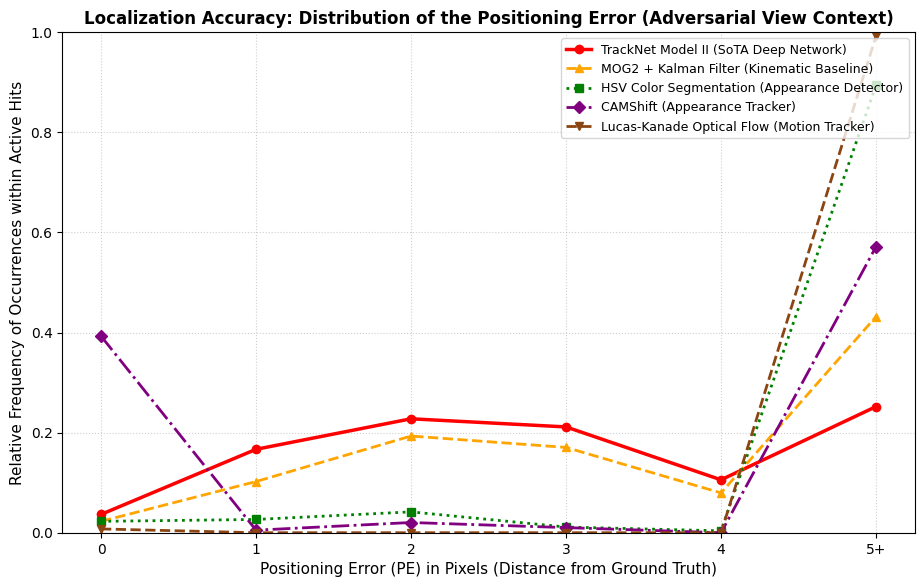

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def generate_five_way_error_chart(tn_errors, kf_errors, hsv_errors, camshift_errors, lk_errors):
    labels = ['0', '1', '2', '3', '4', '5+']

    def process_bins(error_list):
        if len(error_list) == 0: return [0]*6
        arr = np.array(error_list)
        total = len(arr)
        pcts = [np.sum(arr == 0) / total]
        for b in range(1, 5):
            pcts.append(np.sum((arr > b-1) & (arr <= b)) / total)
        pcts.append(np.sum(arr > 4) / total)
        return pcts

    tn_percentages       = process_bins(tn_errors)
    kf_percentages       = process_bins(kf_errors)
    hsv_percentages      = process_bins(hsv_errors)
    camshift_percentages = process_bins(camshift_errors)
    lk_percentages       = process_bins(lk_errors)

    plt.figure(figsize=(11, 6.5))
    plt.plot(labels, tn_percentages, marker='o', color='red', linestyle='-', linewidth=2.5,
             label='TrackNet Model II (SoTA Deep Network)')
    plt.plot(labels, kf_percentages, marker='^', color='orange', linestyle='--', linewidth=2,
             label='MOG2 + Kalman Filter (Kinematic Baseline)')
    plt.plot(labels, hsv_percentages, marker='s', color='green', linestyle=':', linewidth=2,
             label='HSV Color Segmentation (Appearance Detector)')
    plt.plot(labels, camshift_percentages, marker='D', color='purple', linestyle='-.', linewidth=2,
             label='CAMShift (Appearance Tracker)')
    plt.plot(labels, lk_percentages, marker='v', color='saddlebrown', linestyle='--', linewidth=2,
             label='Lucas-Kanade Optical Flow (Motion Tracker)')

    plt.title('Localization Accuracy: Distribution of the Positioning Error (Adversarial View Context)',
              fontsize=12, fontweight='bold')
    plt.xlabel('Positioning Error (PE) in Pixels (Distance from Ground Truth)', fontsize=11)
    plt.ylabel('Relative Frequency of Occurrences within Active Hits', fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.ylim(0, 1.0)
    plt.legend(fontsize=9, loc='upper right')

    print("Generating consolidated five-way tracking localization chart for report presentation...")
    plt.show()

generate_five_way_error_chart(tracknet_pe_list, kalman_pe_list, hsv_pe_list,
                              camshift_pe_list, lk_pe_list)

**Step 11: Consolidated Quantitative Summary Table**


In [11]:
import numpy as np

def _mean(lst):   return np.mean(lst) if len(lst) > 0 else 0.0
def _succ(lst):   return (np.mean(np.array(lst) <= pe_threshold) * 100) if len(lst) > 0 else 0.0

rows = [
    ("TrackNet Model II (SoTA)",      len(tracknet_pe_list), _mean(tracknet_pe_list), _succ(tracknet_pe_list)),
    ("MOG2 + Kalman (Kinematic)",     len(kalman_pe_list),   _mean(kalman_pe_list),   _succ(kalman_pe_list)),
    ("HSV Segmentation (Appearance)", len(hsv_pe_list),      _mean(hsv_pe_list),      _succ(hsv_pe_list)),
    ("CAMShift (Appearance Tracker)", len(camshift_pe_list), _mean(camshift_pe_list), _succ(camshift_pe_list)),
    ("Lucas-Kanade (Motion Tracker)", len(lk_pe_list),       _mean(lk_pe_list),       _succ(lk_pe_list)),
]

print("="*78)
print(f"  DATASET 2 (STRESS-TEST / ADVERSARIAL VIEW) -- LOCALIZATION SUMMARY  | PE thr = {pe_threshold}px")
print("="*78)
print(f"{'Method':<34}{'Locks':>8}{'Mean PE (px)':>16}{'Success@thr':>16}")
print("-"*78)
for name, locks, mpe, succ in rows:
    print(f"{name:<34}{locks:>8}{mpe:>16.2f}{succ:>15.2f}%")
print("="*78)

  DATASET 2 (STRESS-TEST / ADVERSARIAL VIEW) -- LOCALIZATION SUMMARY  | PE thr = 5px
Method                               Locks    Mean PE (px)     Success@thr
------------------------------------------------------------------------------
TrackNet Model II (SoTA)               246           15.42          84.96%
MOG2 + Kalman (Kinematic)              264           17.16          60.23%
HSV Segmentation (Appearance)          264          216.15          10.61%
CAMShift (Appearance Tracker)          196           19.28          43.37%
Lucas-Kanade (Motion Tracker)          264           66.13           1.52%
